In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Loading the parquet file
df = pd.read_parquet("0000 (2).parquet")
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 220000 entries, 0 to 219999
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   site_id              220000 non-null  str    
 1   site_type            220000 non-null  str    
 2   disco                220000 non-null  str    
 3   feeder_id            220000 non-null  str    
 4   timestamp            220000 non-null  str    
 5   active_power_kw      220000 non-null  float64
 6   reactive_power_kvar  220000 non-null  float64
 7   pf                   220000 non-null  float64
 8   energy_kwh           220000 non-null  float64
 9   voltage_ll_v         220000 non-null  float64
 10  current_a            220000 non-null  float64
dtypes: float64(6), str(5)
memory usage: 31.8 MB


In [4]:
df.head()

,site_id,site_type,disco,feeder_id,timestamp,active_power_kw,reactive_power_kvar,pf,energy_kwh,voltage_ll_v,current_a
0,IND-00000000,industrial,Abuja,ABJ-SS-001-FD-083,2024-06-10 05:00:00,404.809,196.058,0.90,404.809,405.5,640.39
1,IND-00000001,industrial,Kaduna,KAD-SS-001-FD-043,2024-06-09 09:00:00,340.881,112.042,0.95,340.881,387.0,535.25
2,IND-00000002,industrial,Kano,KNO-SS-002-FD-013,2024-09-27 04:00:00,34.647,11.388,0.95,34.647,398.3,52.86
3,COM-00000003,commercial,Jos,JOS-SS-001-FD-057,2024-04-21 16:00:00,58.856,31.767,0.88,58.856,412.8,93.54
4,COM-00000004,commercial,Kaduna,KAD-SS-002-FD-004,2024-11-10 07:00:00,60.110,25.607,0.92,60.110,420.1,89.79


In [5]:
df.shape

(220000, 11)

In [6]:
df = df.drop_duplicates()
df.columns

Index(['site_id', 'site_type', 'disco', 'feeder_id', 'timestamp',
       'active_power_kw', 'reactive_power_kvar', 'pf', 'energy_kwh',
       'voltage_ll_v', 'current_a'],
      dtype='str')

In [7]:
df.describe(include="all")

,site_id,site_type,disco,feeder_id,timestamp,active_power_kw,reactive_power_kvar,pf,energy_kwh,voltage_ll_v,current_a
count,220000,220000,220000,220000,220000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000
unique,220000,2,10,2737,8760,NaN,NaN,NaN,NaN,NaN,NaN
top,IND-00000000,commercial,Ibadan,EKO-SS-002-FD-102,2024-07-09 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,131577,22173,125,46,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,178.873852,86.029820,0.899958,178.873852,399.858629,287.723477
std,NaN,NaN,NaN,NaN,NaN,226.766514,111.937087,0.030213,226.766514,14.640349,365.565284
min,NaN,NaN,NaN,NaN,NaN,1.965000,0.756000,0.850000,1.965000,360.000000,3.370000
25%,NaN,NaN,NaN,NaN,NaN,29.957750,13.906000,0.880000,29.957750,389.900000,48.100000
50%,NaN,NaN,NaN,NaN,NaN,61.554500,29.361000,0.900000,61.554500,400.000000,99.000000
75%,NaN,NaN,NaN,NaN,NaN,276.160750,128.241000,0.920000,276.160750,410.100000,443.135000


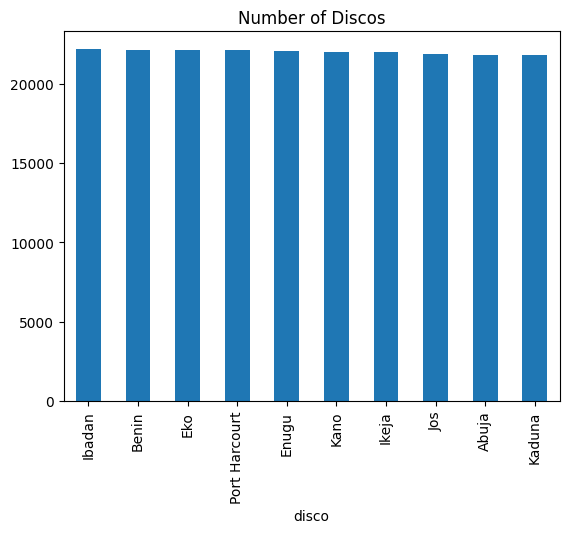

In [9]:
df["disco"].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Number of Discos")
plt.show()

In [10]:
df["site_type"].value_counts().sort_values(ascending=False)

site_type
commercial    131577
industrial     88423
Name: count, dtype: int64

In [11]:
df.groupby("disco")["active_power_kw"].sum().sort_values(ascending=False)

disco
Kano             3996896.530
Benin            3956028.437
Jos              3948881.830
Enugu            3941961.552
Port Harcourt    3939298.747
Eko              3933678.678
Ikeja            3921702.966
Ibadan           3913958.010
Kaduna           3905615.070
Abuja            3894225.717
Name: active_power_kw, dtype: float64

In [12]:
df.groupby("disco")["reactive_power_kvar"].sum().sort_values(ascending=False)

disco
Kano             1921905.878
Benin            1904632.744
Jos              1902138.233
Port Harcourt    1894131.286
Eko              1892657.140
Enugu            1892566.312
Ikeja            1888653.177
Ibadan           1881703.663
Kaduna           1877778.557
Abuja            1870393.422
Name: reactive_power_kvar, dtype: float64

In [13]:
df.groupby("disco")["energy_kwh"].sum().sort_values(ascending=False)

disco
Kano             3996896.530
Benin            3956028.437
Jos              3948881.830
Enugu            3941961.552
Port Harcourt    3939298.747
Eko              3933678.678
Ikeja            3921702.966
Ibadan           3913958.010
Kaduna           3905615.070
Abuja            3894225.717
Name: energy_kwh, dtype: float64

In [14]:
df.groupby("disco")["voltage_ll_v"].sum().sort_values(ascending=False)

disco
Ibadan           8862901.2
Benin            8854467.4
Port Harcourt    8833351.8
Eko              8831907.8
Enugu            8820390.1
Kano             8794428.4
Ikeja            8793193.9
Jos              8745305.7
Abuja            8720309.5
Kaduna           8712642.5
Name: voltage_ll_v, dtype: float64

In [15]:
#Save new file as csv
df.to_csv("distribution_1.csv")